In [ ]:
# Copy the project files and set up Colab
# This will require restarting the runtime
# You do not need to run this cell again after restarting
!git clone https://github.com/samadams8/UT_GerryChain.git
!git lfs pull
%pip install -e UT_GerryChain/

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

In [1]:
# outputs_path = "/content/drive/MyDrive/UT_GerryChain" # @param {"type":"string"}
# repo_dir = "UT_GerryChain"
outputs_path = "output/gcloud"
repo_dir = "."
map_type = "us_house" # @param ["us_house","ut_house","ut_senate"]


In [2]:
import os
from datetime import datetime as dt
from math import floor, ceil
import json

from utgc import GeographyManager, ConfigurationManager, precondition
import utgc.notebookhelper as nbh
from utgc.chain import CouponCollectorChain, coupon_collector_expectation
from gerrychain.chain import MarkovChain

nbh.suppress_colab_warnings()

# Retrieves basic configuration parameters based on type of maps to draw
params = nbh.get_notebook_params(map_type, repo_dir=repo_dir)
# Total number of maps to draw
num_steps = 100

# Configuration files and example maps will be saved to a tagged directory
config_tag = params["prefix"] + ""  # <-- Change this to something descriptive if desired

# Where the configuration file and all related results will be saved
config_dir = os.path.join(outputs_path, config_tag or dt.now().strftime("%Y%m%d%H%M%S"))
run_name = "ensemble"

save_dir = os.path.join(config_dir, run_name)
os.makedirs(os.path.join(save_dir, "maps"), exist_ok=True)

print(f"Output will be saved to {save_dir}")

Output will be saved to output/gcloud/us_house/ensemble


In [3]:
# Data file path
geo = GeographyManager(
    pop_data={
        params["data_tag"]: {
            "data": params["data_path"],
            "transitability": params["transitability_path"],
        }
    },
    crs="EPSG:26912",
)
geo.fill_empty_ids(params["data_tag"], ["MUNIID"])

In [4]:
import glob

initial_plan = params["init_plan_path"]
start_step = 0
shapefiles_dir = os.path.join(save_dir, "maps", "shapefiles")
if os.path.exists(shapefiles_dir):
    saved_zips = glob.glob(os.path.join(shapefiles_dir, "step_*.zip"))
    if saved_zips:
        last_file = max(saved_zips)
        filename = os.path.basename(last_file)
        start_step = int(filename.split("_")[1].split(".")[0]) + 1
        initial_plan = last_file
        print(f"Resuming from step {start_step-1} using {last_file}")

num_districts = nbh.get_district_count(initial_plan)
print(f"Number of districts: {num_districts}")

Number of districts: 4


In [5]:
cfg = ConfigurationManager()
cfg = cfg.set_pop_column("TOTPOP")
cfg = cfg.add_pop_dev_updater()

# Population deviation tolerance is passed to proposal() and precondition() directly.
# That call uses pop_tolerance=0.001 (0.1%). No separate set_pop_dev_tolerance method.
cfg = (cfg
    # How can municipalities be split?
    .constrain_region_splits(
        name="muni",
        column_id="MUNIID",
        # How many municipalities can be split total?
        num_split=num_districts-1, #floor(num_districts / 2),
        # How many splits past the first for each muni are allowed (map wide)?
        num_multi_splits=num_districts-1, #floor(num_districts / 6),
    )
    # No muni split constraint--just track it.
    # .add_locality_splits_updater(
    #     name="muni",
    #     column_id="MUNIID",
    # )
    # How can counties be split?
    .constrain_region_splits(
        name="county",
        column_id="COUNTYID",
        # How many counties can be split total?
        num_split=num_districts-1, #round(num_districts / 2) + 1,
        # How many splits past the first for each county are allowed (map wide)?
        num_multi_splits=num_districts-1, #floor(num_districts / 5),
    )
    # Whether to prevent the algorithm from drawing the same map twice in a row
    .constrain_not_equal(not_equal_constraint=True)
)

In [6]:
cfg = (cfg
    ### Region surcharge configuration ###
    # Municipalities
    .surcharge_region(column_id="MUNIID", surcharge=1)
    # Counties
    # .surcharge_region(column_id="COUNTYID", surcharge=0.8)
    .surcharge_region(column_id="COUNTYID", surcharge=0.5)
    # Institutions of higher education
    .surcharge_region(column_id="HIGHEREDID", surcharge=0.2)
    # Indian Reservations (American Indian / Alaska Native Areas)
    .surcharge_region(column_id="AIANNHID", surcharge=0.2)
    # Military Installations
    .surcharge_region(column_id="MILITID", surcharge=0.2)
    # Metro/micropolitan areas (CBSA – Core Based Statistical Areas)
    .surcharge_region(column_id="CBSAID", surcharge=0.1)

    ### Edge penalty configuration ###
    # Transitability
    .set_edge_penalty_scale(0.3)
)

cfg = (cfg
    .add_shape_metrics(["polsby_popper"])
)

In [7]:
# Build election dictionaries from the geospatial columns.
election_dicts = geo.build_election_dicts(
    params["data_tag"],
    years=[2016, 2020, 2024],
    offices=["PRE", "GOV", "ATG", "AUD", "TRE"],
    parties=["D", "R", "-"],
    overrides={"2024GOV": {"R1": "G24GOVRHEN", "R2": "G24GOVNCLA"}},
)

cfg = (cfg
    .add_election_updaters(
        elections=election_dicts,
        skip_if_missing_parties=True
    )
    .add_election_aggregator(
        name="2020",
        elections=["2020PRE"],
        parties=["D", "R", "-"],
    )
    .add_election_metric_updaters(
        "2020",
        [
            "efficiency_gap", "stdev_partisan_share",
            "majority_partisan_shares", "majority_seats",
        ],
        prepend_agg_name=True
    )
    .add_election_aggregator(
        name="2024",
        elections=["2024PRE"],
        parties=["D", "R", "-"],
    )
    .add_election_metric_updaters(
        "2024",
        [
            "efficiency_gap", "stdev_partisan_share",
            "majority_partisan_shares", "majority_seats",
        ],
        prepend_agg_name=True
    )
    .add_election_aggregator(
        name="SB1011",
        elections=[
            "2016PRE", "2016GOV", "2016ATG", "2016AUD", "2016TRE",
            "2020PRE", "2020GOV", "2020ATG",
            "2024PRE", "2024GOV", "2024ATG", "2024AUD", "2024TRE",
        ],
        parties=["D", "R", "-"],
    )
    .add_election_metric_updaters(
        "SB1011",
        [
            "partisan_bias_utah", "partisan_bias", "mean_median",
            "efficiency_gap", "stdev_partisan_share",
            "majority_partisan_shares", "majority_seats",
        ],
        prepend_agg_name=True,
    )
)

cfg.to_config(os.path.join(save_dir, "config.yaml"))

In [8]:
comparison_results_path = os.path.join(save_dir, "comparison_maps.json")
if os.path.exists(comparison_results_path):
    print("Loading pre-computed comparison maps performance")
    with open(comparison_results_path, "r") as f:
        comparison_maps = json.load(f)
else:
    print("Computing performance of comparison maps")
    def compute_metrics_for_map(shapefile_path, geo, cfg, pop_key=params["data_tag"]):
        """Return a dict of output_updater values for a given electoral map."""
        partition = geo.build_partition(
            pop_key=pop_key,
            plan=shapefile_path,
            updaters=cfg.updaters,
        )
        return nbh.get_updater_values(partition, cfg.updaters_to_save)

    comparison_maps = {}
    for k, v in params["comparison_maps"].items():
        print(f"  {k}...")
        comparison_maps[k] = compute_metrics_for_map(v, geo, cfg)

    with open(comparison_results_path, "w") as f:
        json.dump(comparison_maps, f, indent=2)
    print("Done!")

Computing performance of comparison maps
  Map C...
  Plaintiff 1...
  Plaintiff 2...
  2021 Enacted...
  UIRC Orange...
  UIRC Purple...
  UIRC Public...
Done!


In [9]:
from gerrychain.accept import always_accept
import utgc.plotting as gcplt

munis, counties = nbh.load_boundaries_from_shapefiles(repo_dir=repo_dir)

initial_partition = geo.build_partition(
    pop_key=params["data_tag"],
    plan=initial_plan,
    updaters=cfg.updaters,
)
total_pop = sum(initial_partition["population"].values())
pop_tolerance = params["pop_tolerance"]

remaining_steps = max(0, num_steps - start_step)
proposal = cfg.proposal(
    initial_partition,
    total_population=total_pop,
    pop_tolerance=pop_tolerance,
    edge_weights=geo.get_edge_weights(params["data_tag"]),
)
chain = CouponCollectorChain(
    proposal=proposal,
    constraints=cfg.constraints,
    accept=always_accept,
    initial_state=initial_partition,
    micro_steps_per_yield=ceil(coupon_collector_expectation(num_districts)),
    num_macro_steps=remaining_steps,
)

Loaded 29 counties from ./data/bounds/UtahCountyBoundaries/ut_cnty_2020_bound.shp
Loaded 259 municipalities from ./data/bounds/UtahMunicipalBoundaries/Municipalities.shp


=== MCMC ensemble ===
Running Markov chain (Batched/Coupon Collector)...


  0%|          | 0/100 [00:00<?, ?it/s]

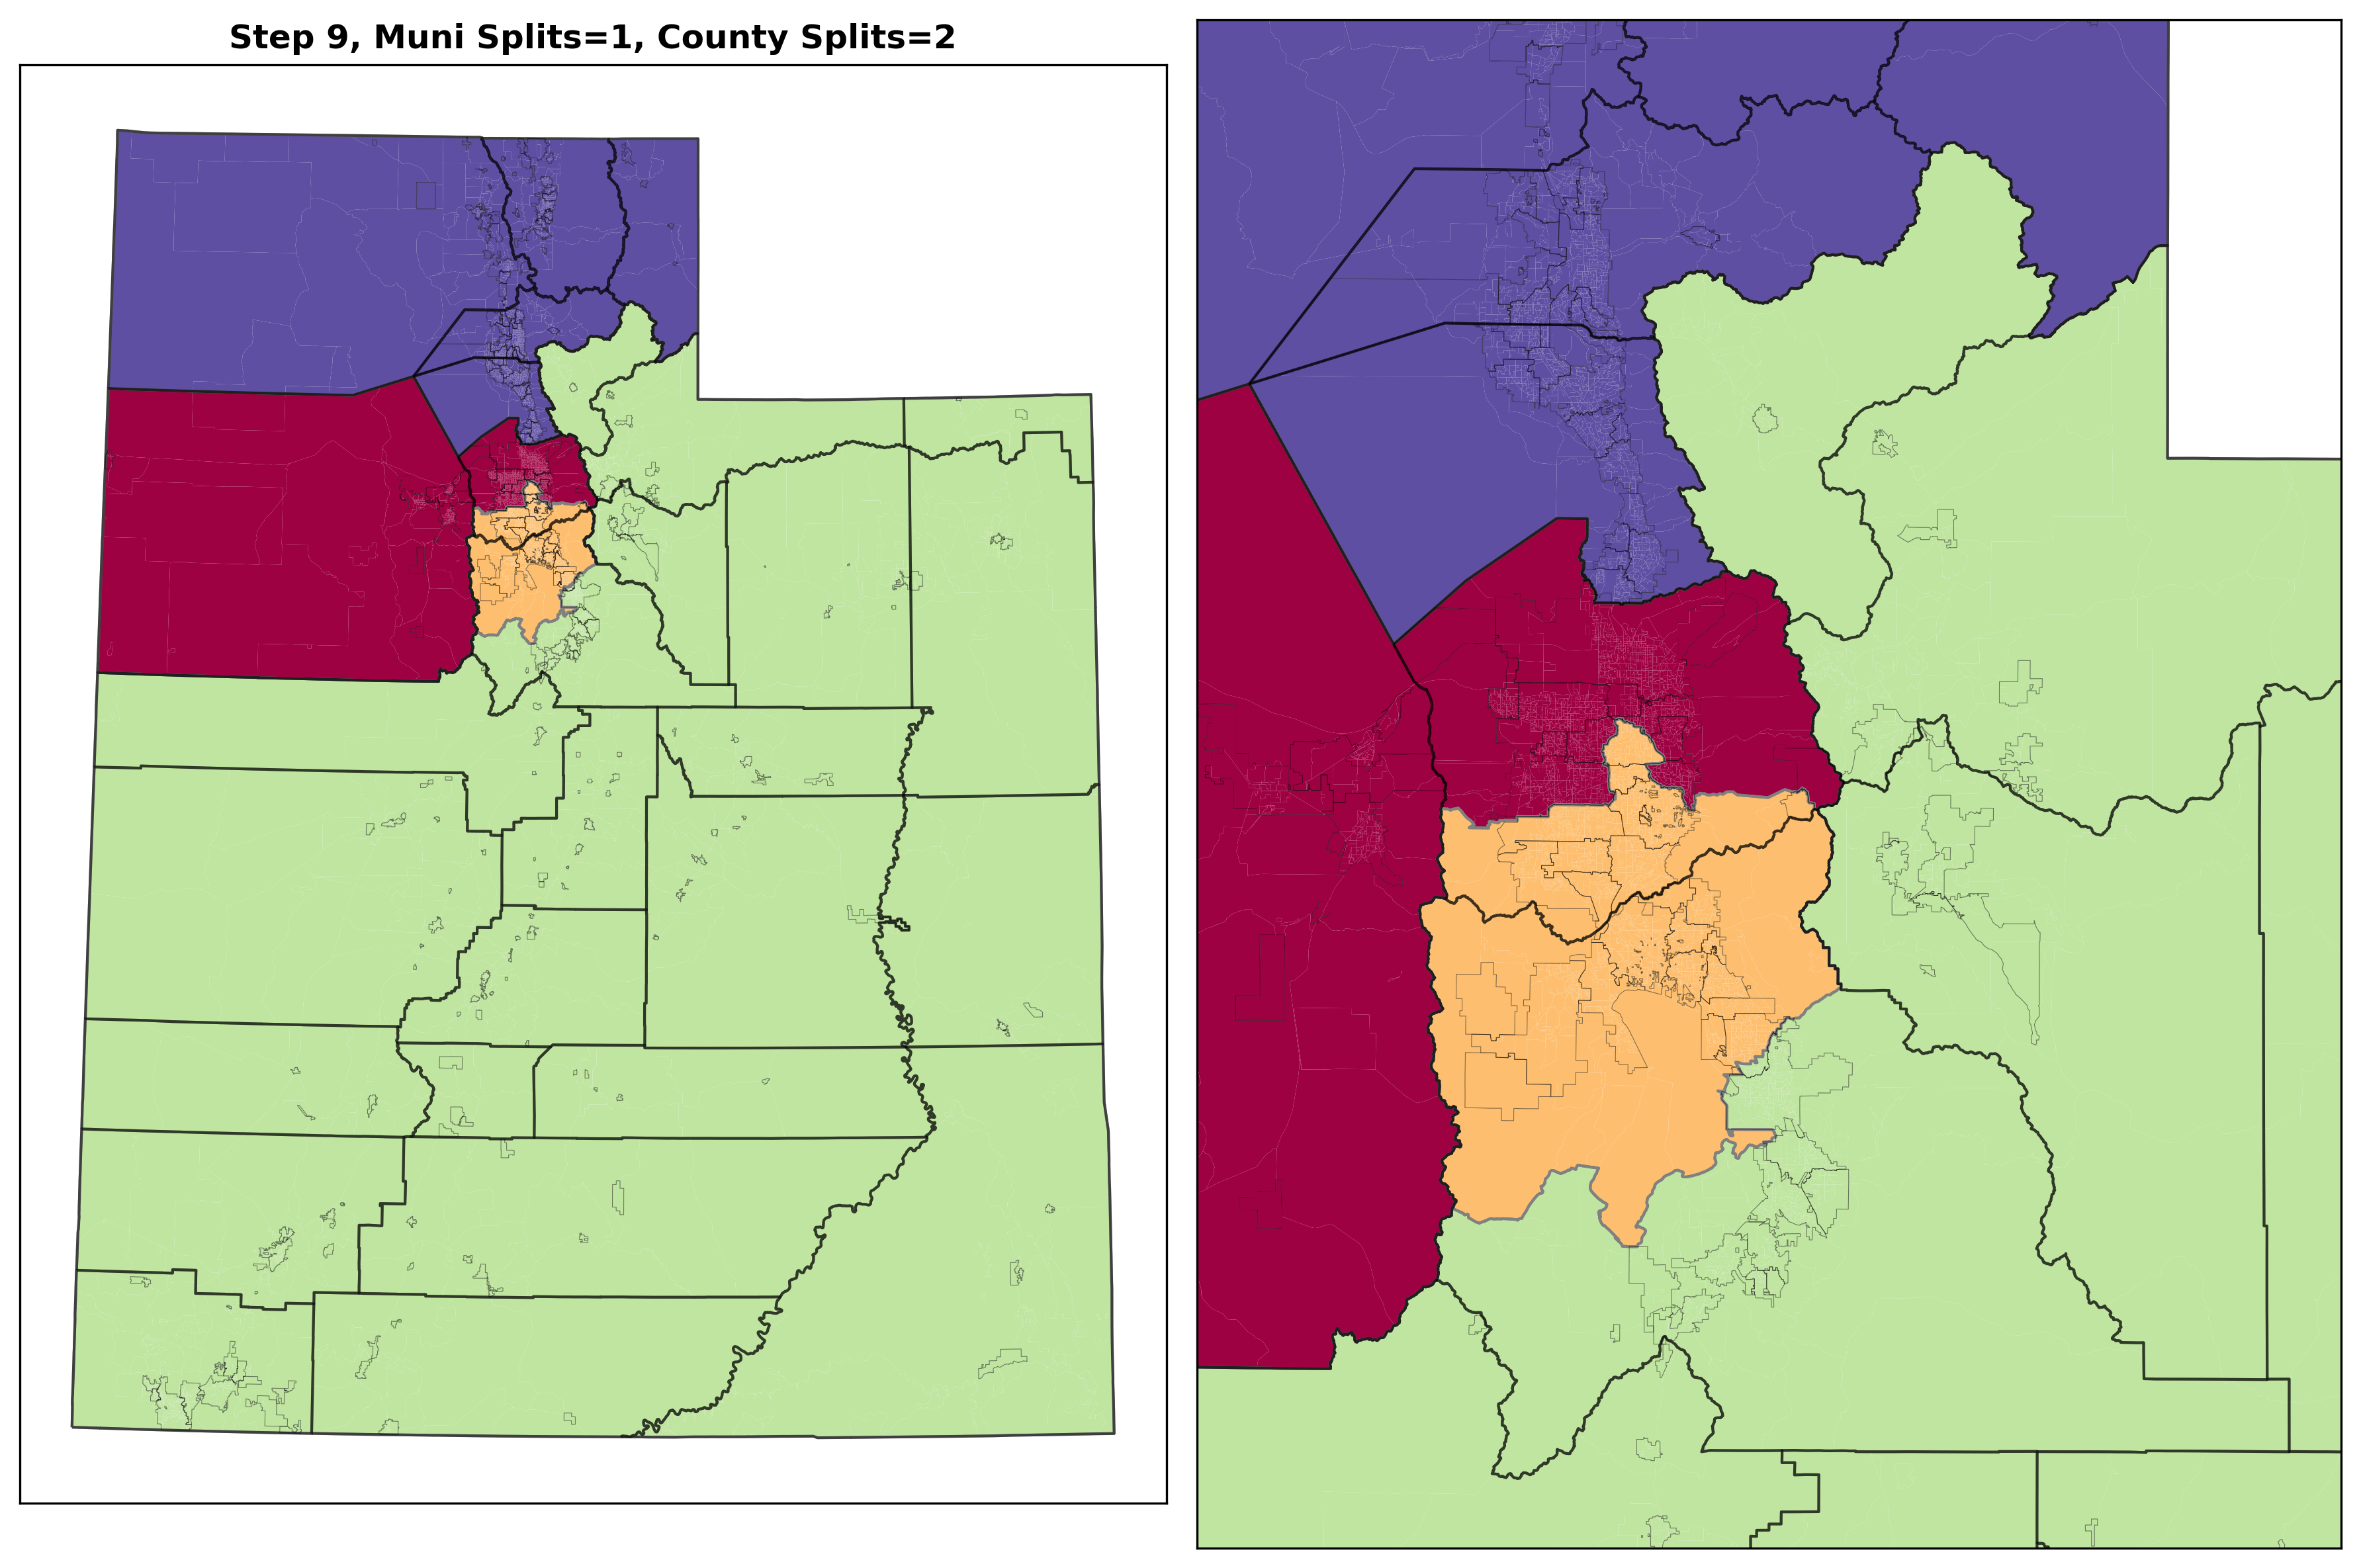

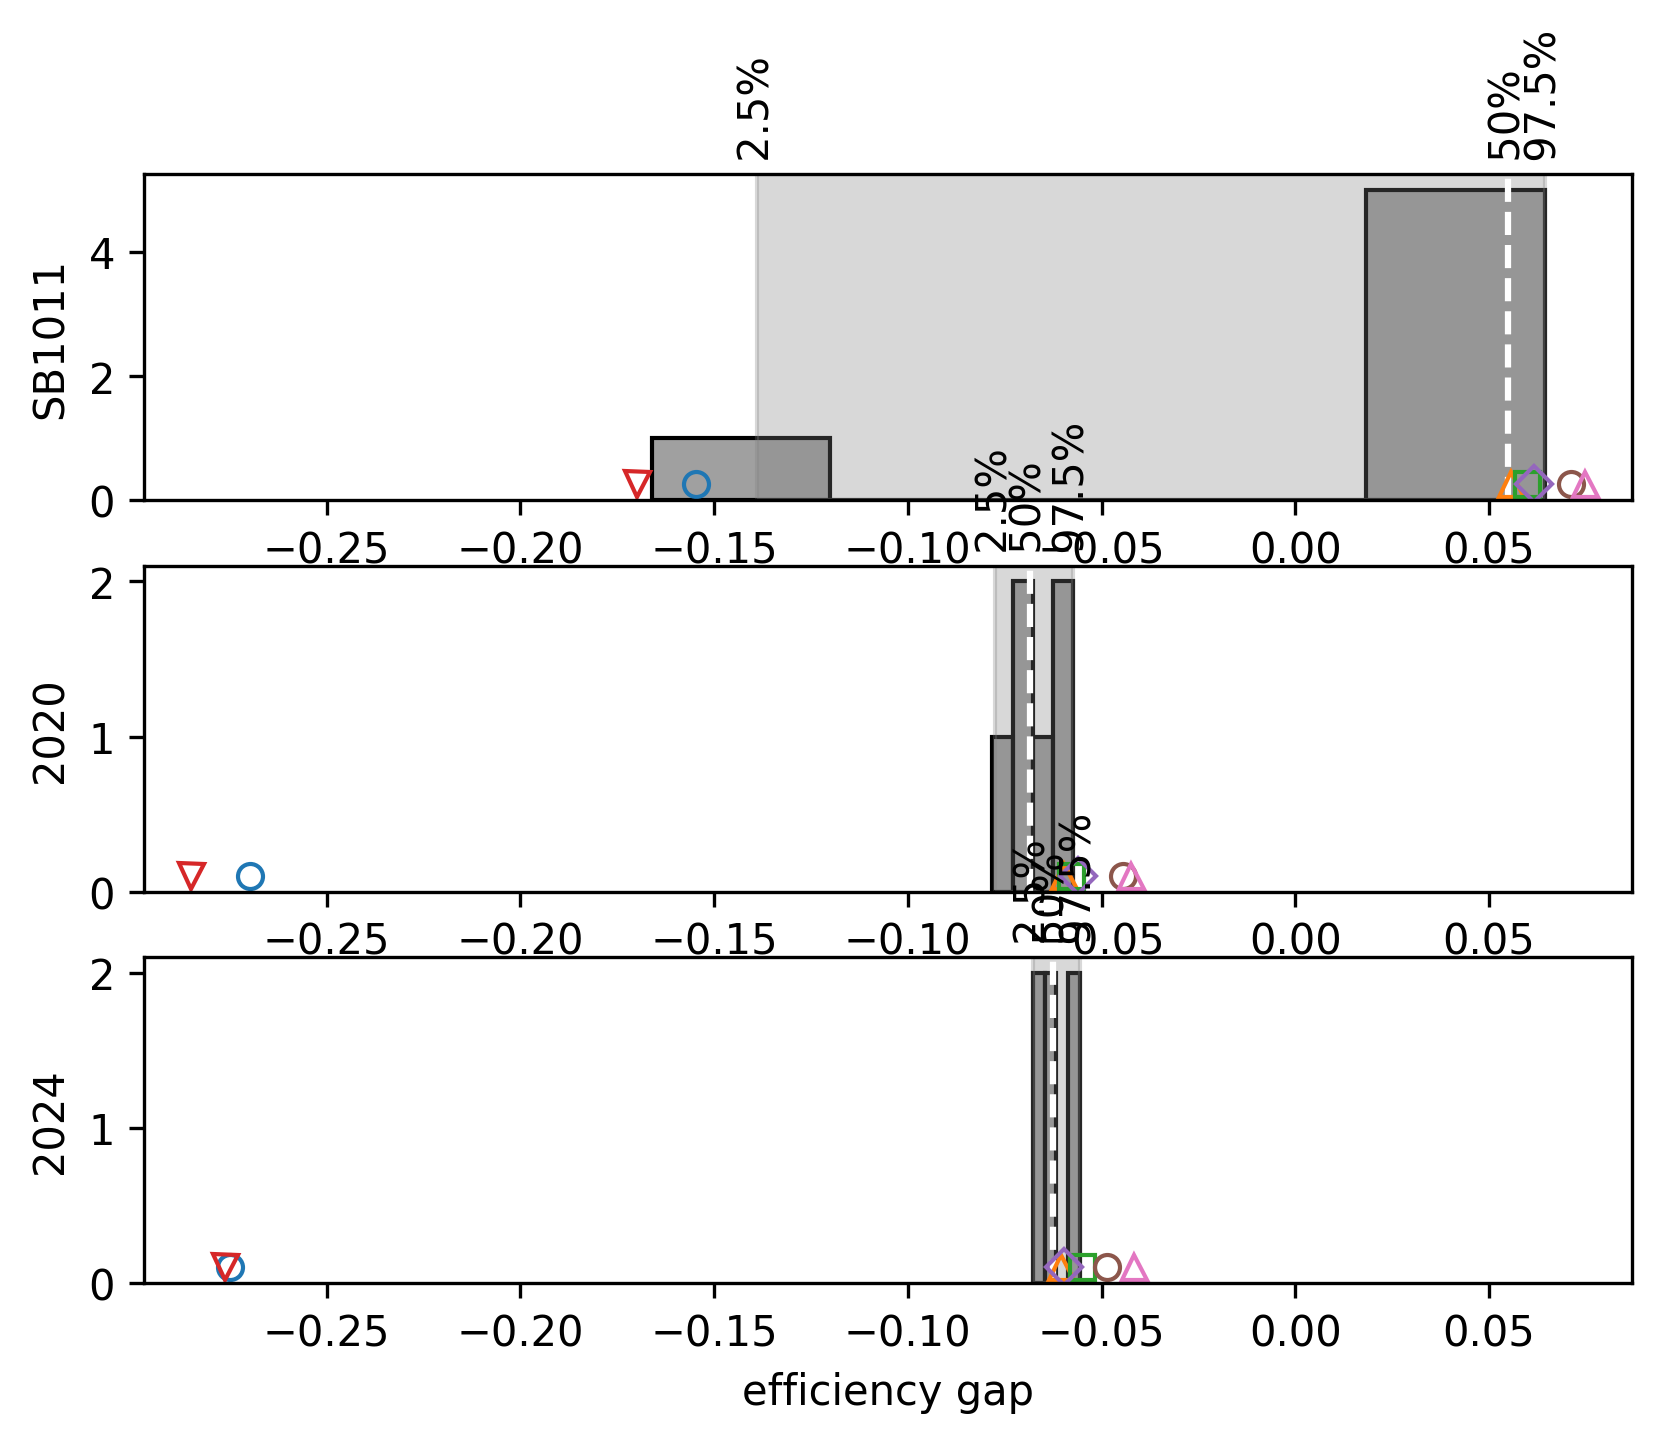

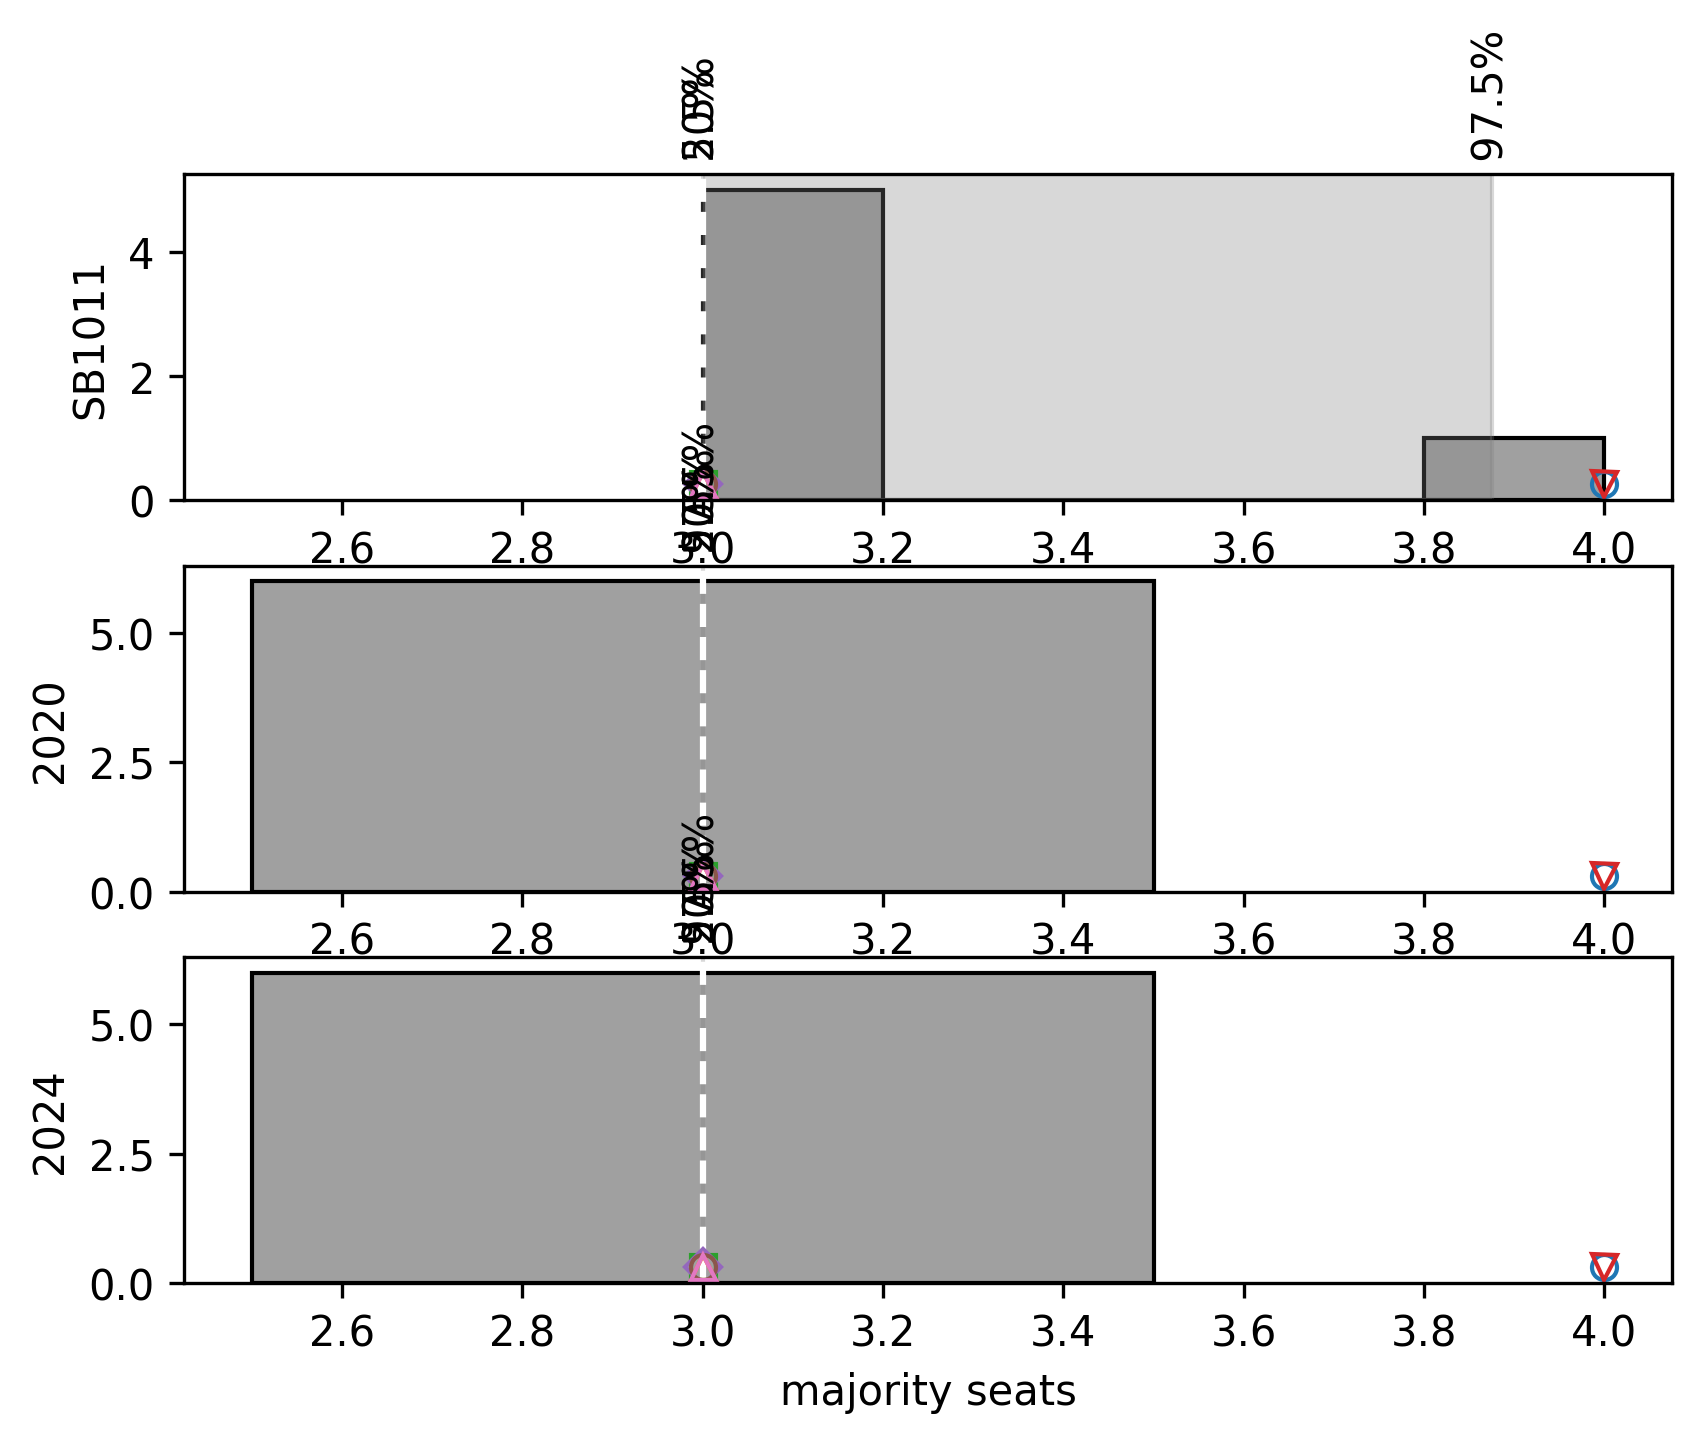

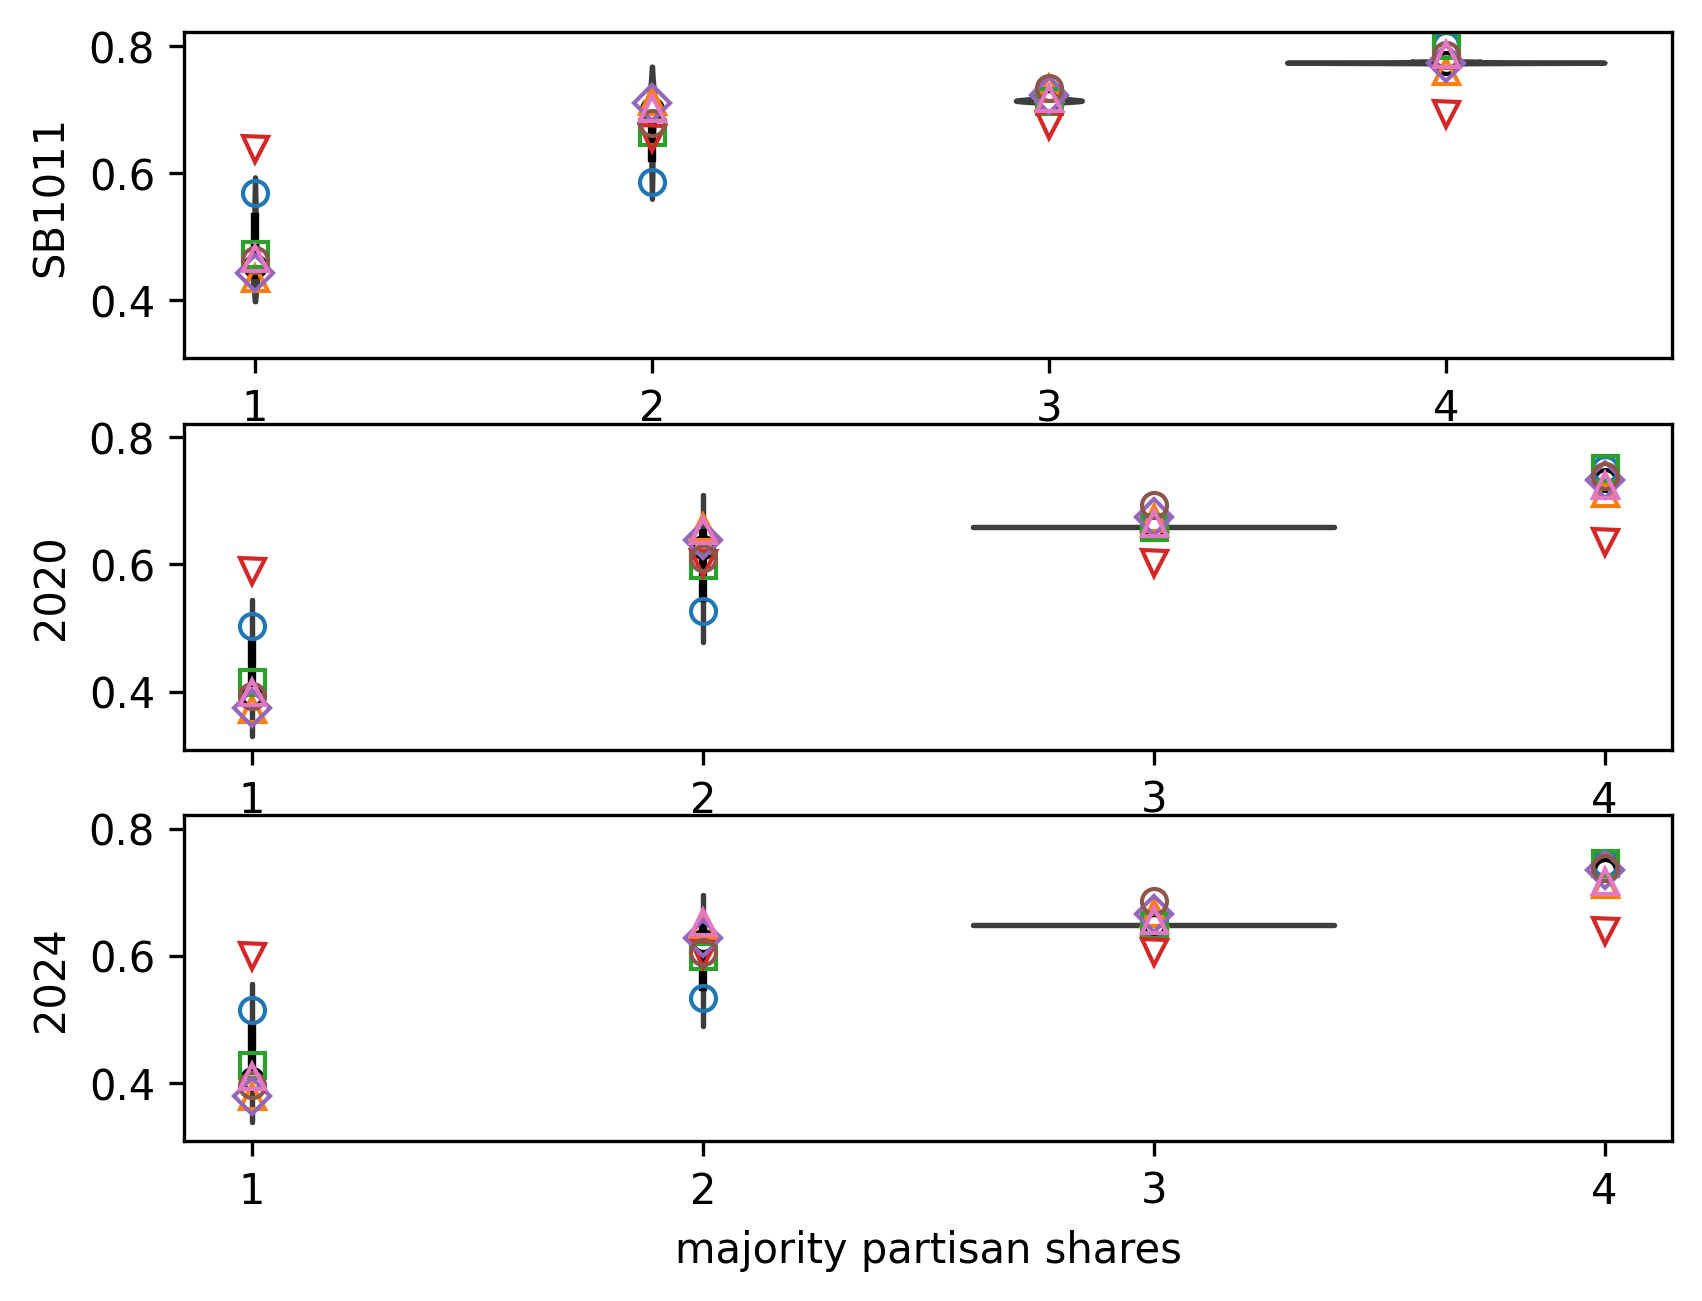

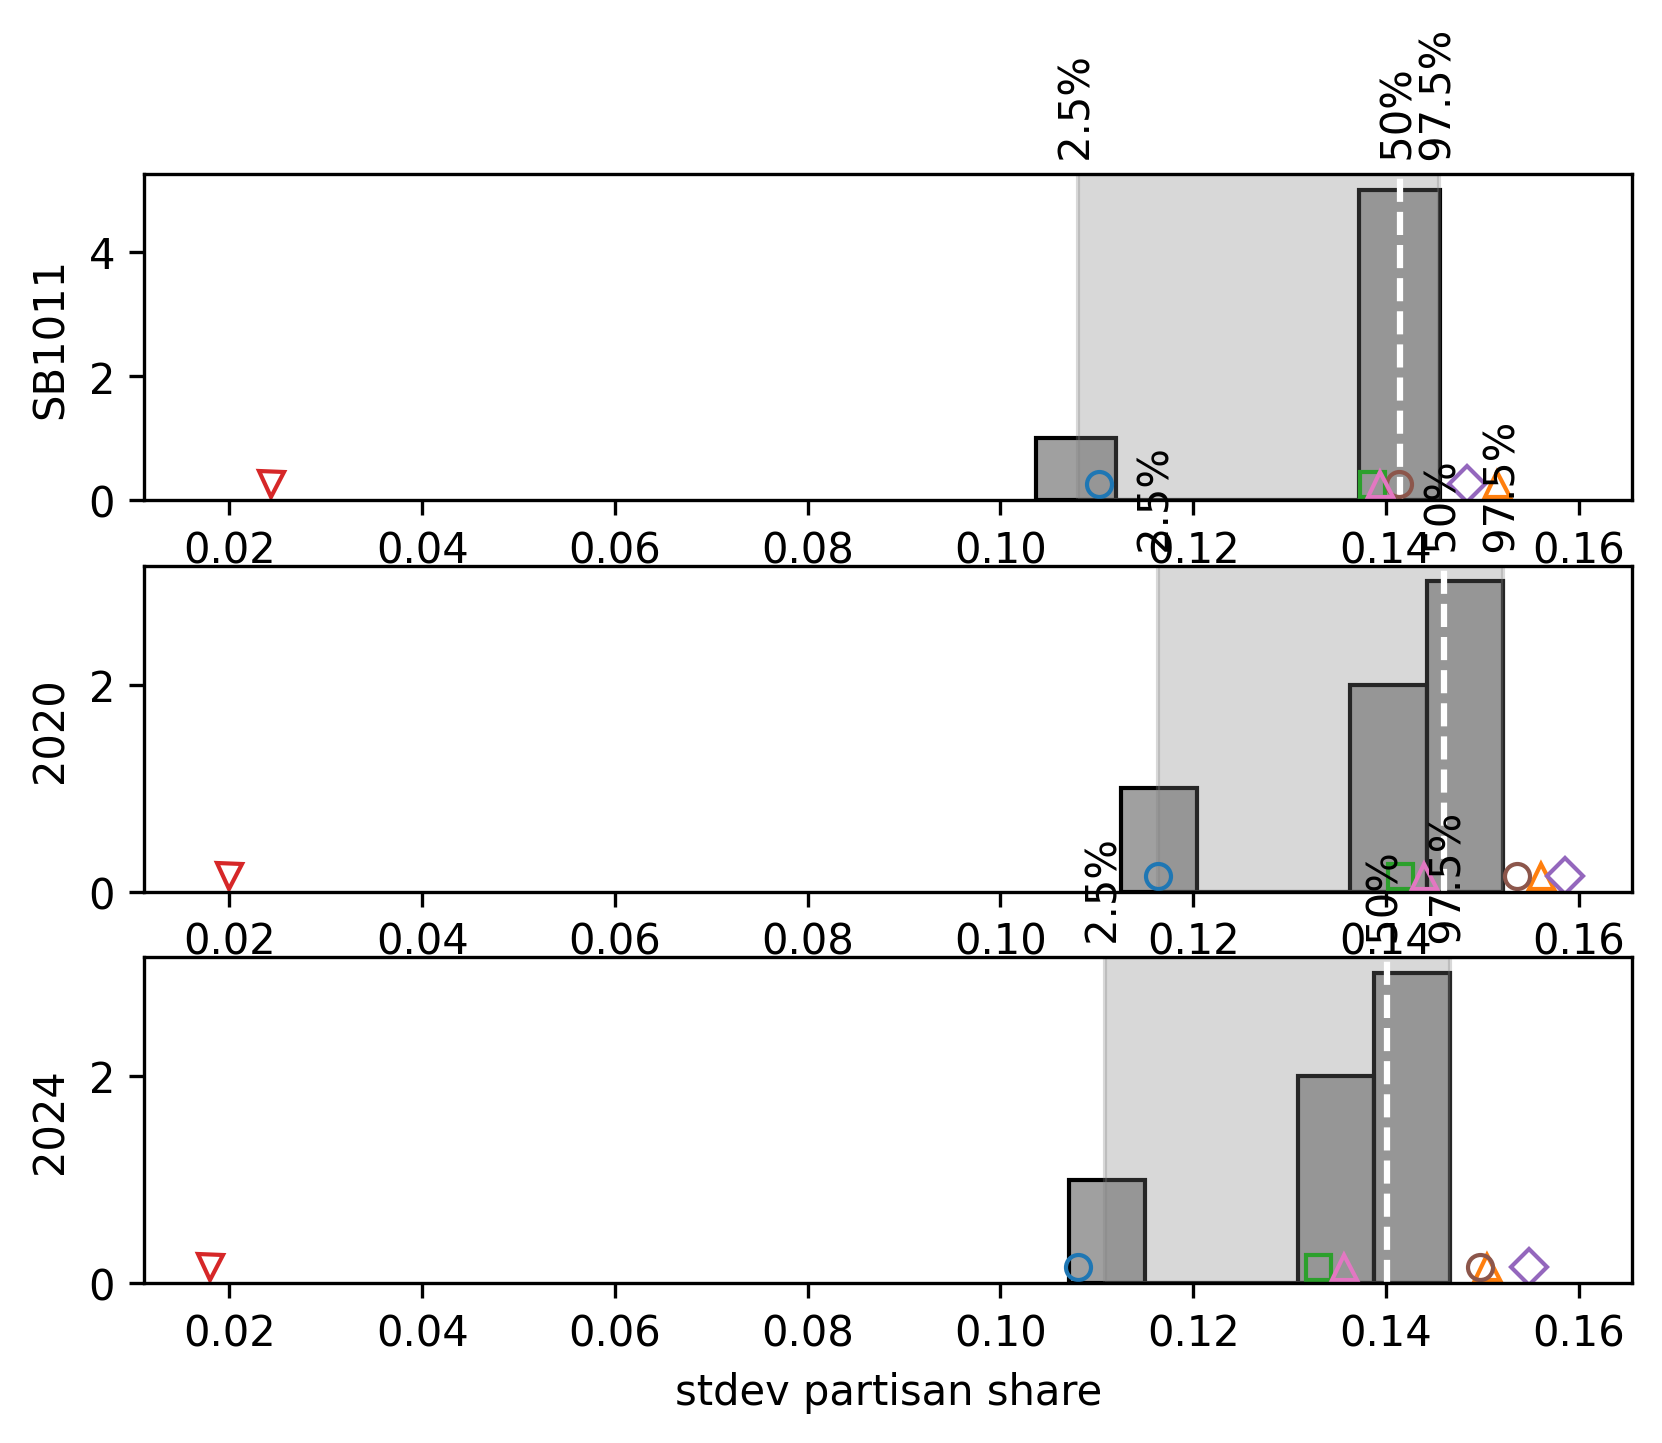

KeyboardInterrupt: 

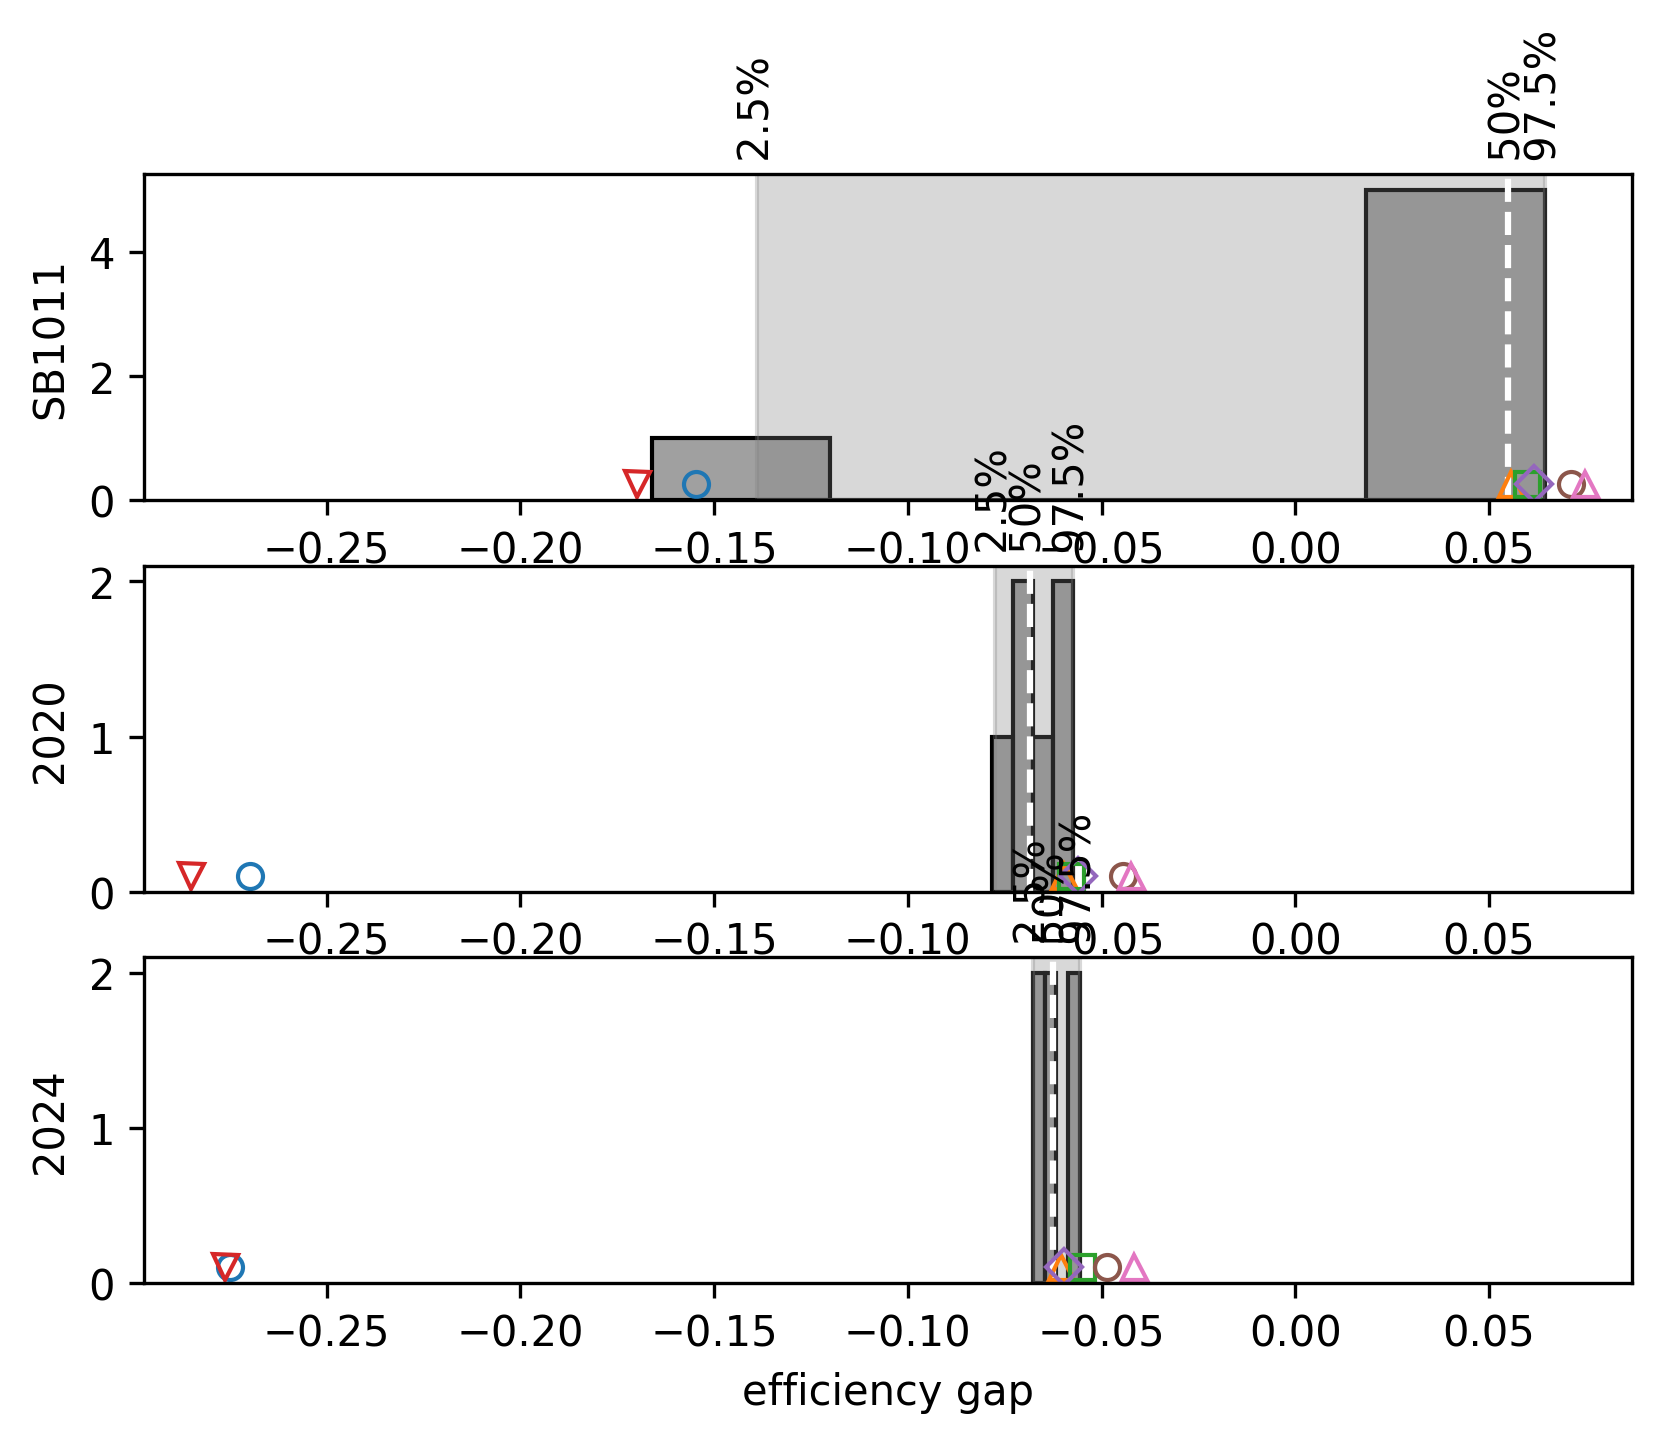

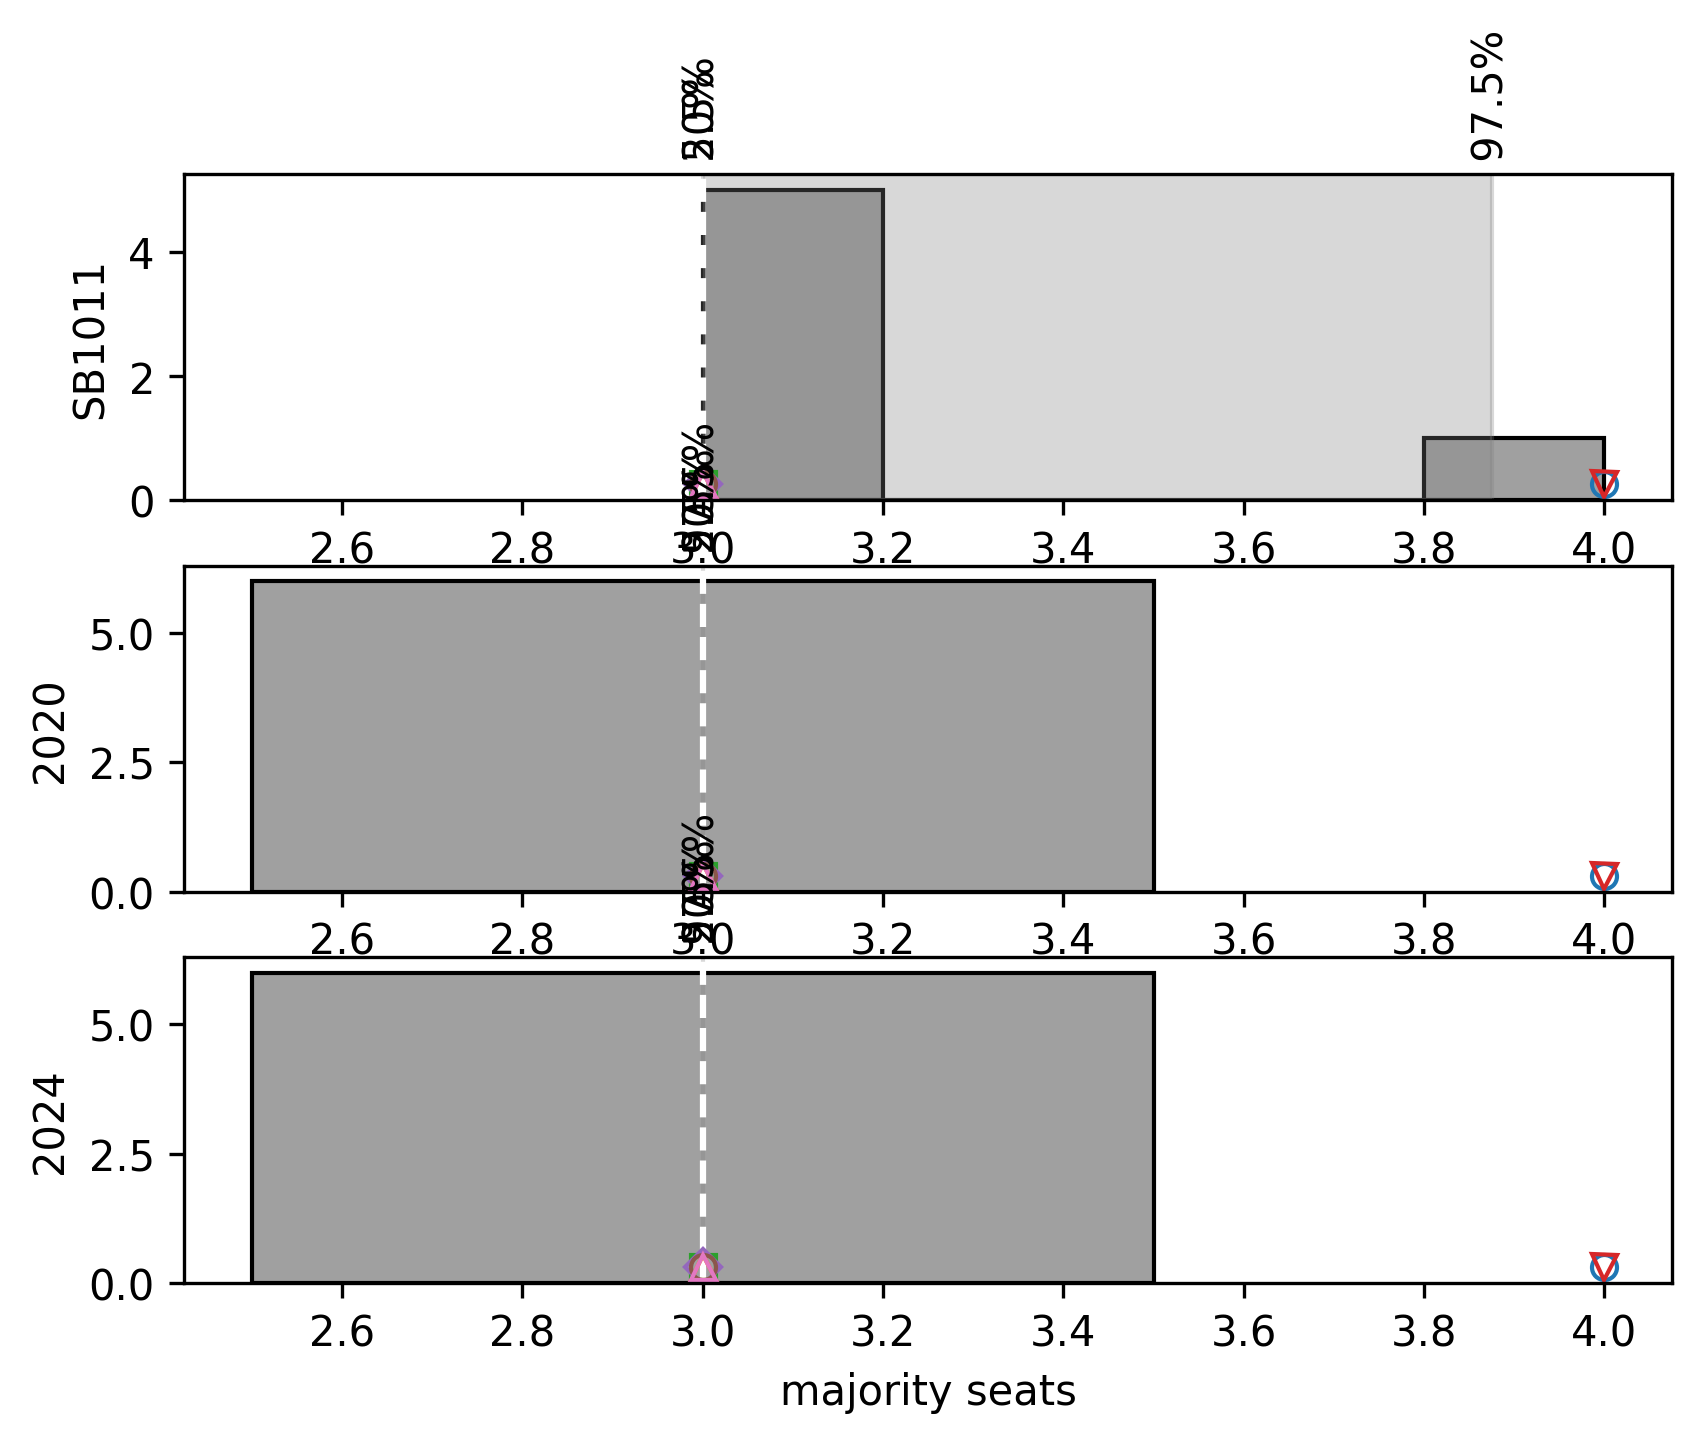

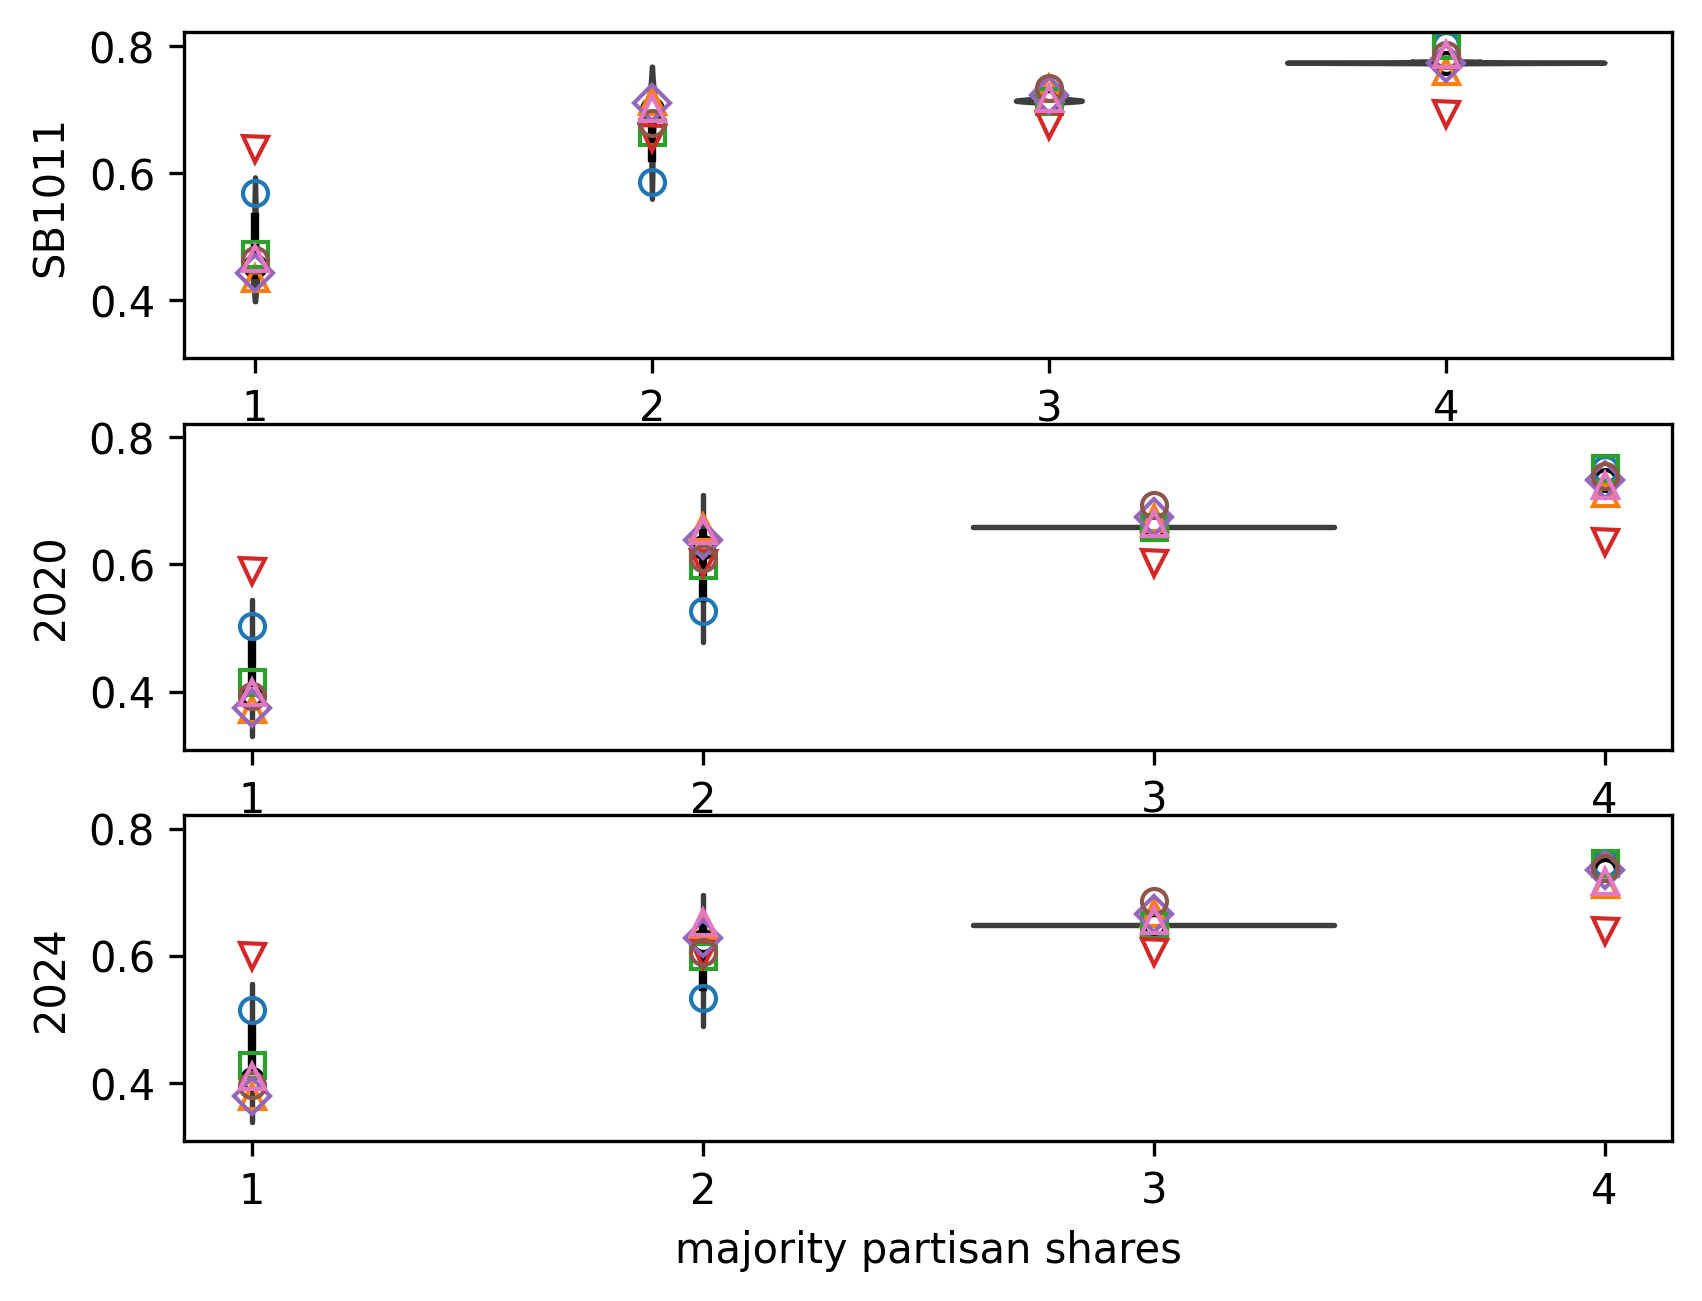

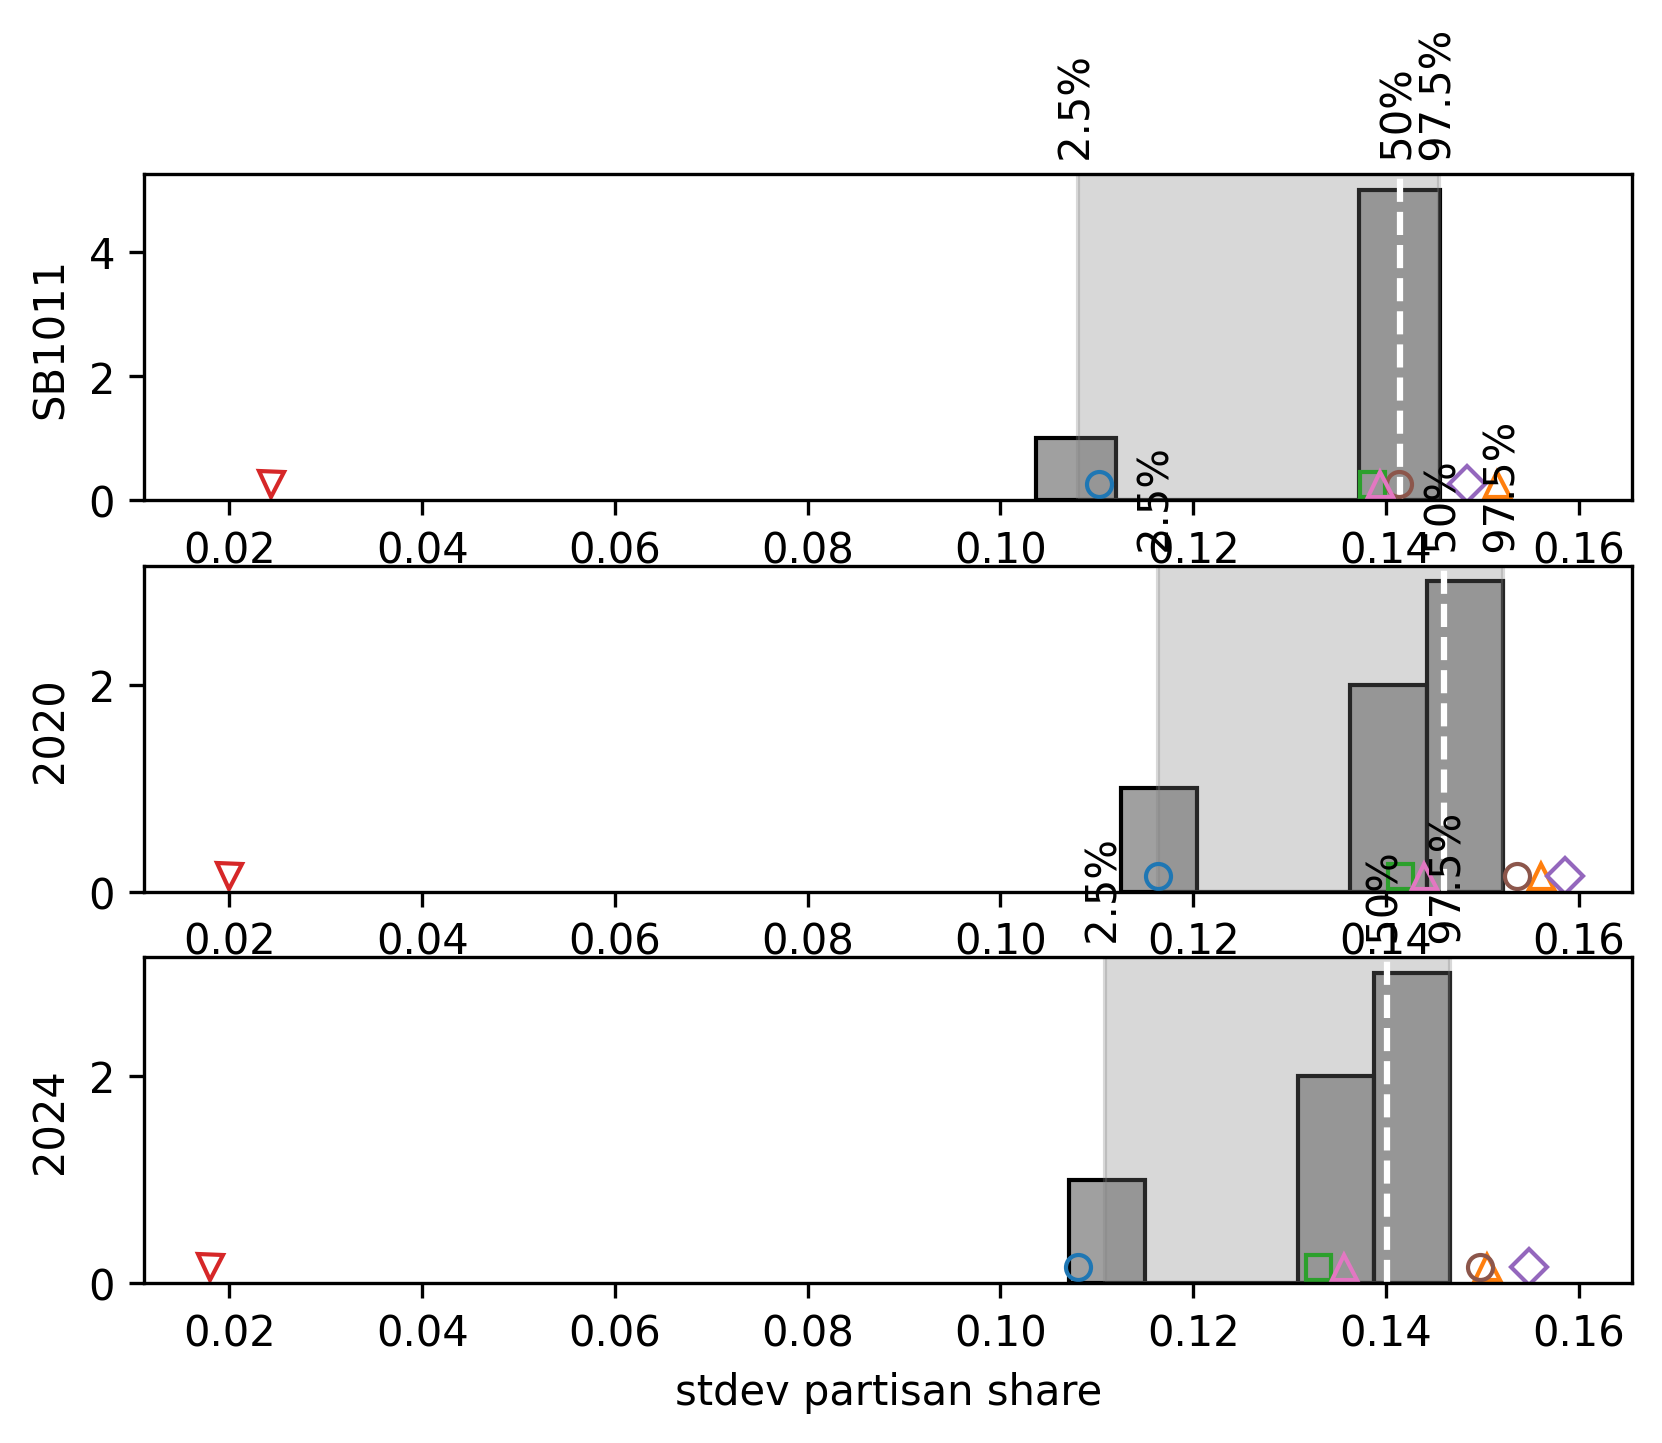

In [10]:
from IPython.display import display, Image
import matplotlib.pyplot as plt
import utgc.results as gcres
import utgc.plotting as gcplt

print(f"=== MCMC {run_name} ===")
print("Running Markov chain (Batched/Coupon Collector)...")
partition_iterator = chain.with_progress_bar()

output_path = os.path.join(save_dir, "output.jsonl")

# For inline display and update of figure
handles = [
    display(display_id=True),
    display(display_id=True),
    display(display_id=True),
    display(display_id=True),
    display(display_id=True),
]

file_mode = "a" if start_step > 0 else "w"
with open(output_path, file_mode) as f:
    for idx, partition in enumerate(partition_iterator):
        step_number = idx + start_step
        # Save metrics (output_updaters subset only)
        data = (
            {"step": step_number}
            | nbh.get_updater_values(partition, cfg.updaters_to_save)
        )
        f.write(json.dumps(data) + "\n")
        f.flush()

        nbh.save_partition(
            partition,
            os.path.join(save_dir,"maps","shapefiles",f"step_{step_number:05d}.zip"),
            geo.get_pop_geodata(params["data_tag"])
        )

        # Plot ordinary map
        gcplt.visualize_partition(
            partition, step_number, os.path.join(save_dir, "maps"),
            counties=counties, municipalities=munis,
            split_munis_count=partition["split_muni"],
            split_counties_count=partition["split_county"],
        )
        # Plot map with partisanship
        gcplt.visualize_partition(
            partition, step_number, os.path.join(save_dir, "maps", "partisanship"),
            counties=counties, municipalities=munis,
            split_munis_count=partition["split_muni"],
            split_counties_count=partition["split_county"],
            color_by="2024_majority_partisan_shares",
            colormap="coolwarm"
        )

        partition.parent = None

        # Update the display handle with the new image
        img_path = os.path.join(save_dir, "maps", f"step_{step_number:05d}.png")
        handles[0].update(Image(filename=img_path))

        if step_number >= 5 and step_number % 5 == 0:
            handles[1].update(nbh.multi_distribution_figure(
                ["SB1011", "2020", "2024"], "efficiency_gap",
                output_path, comparison_maps
            ))
            handles[2].update(nbh.multi_distribution_figure(
                ["SB1011", "2020", "2024"], "majority_seats",
                output_path, comparison_maps
            ))
            handles[3].update(nbh.multi_districts_figure(
                ["SB1011", "2020", "2024"],
                "majority_partisan_shares",
                output_path,
                comparison_maps
            ))
            handles[4].update(nbh.multi_distribution_figure(
                ["SB1011", "2020", "2024"], "stdev_partisan_share",
                output_path, comparison_maps
            ))

print("Done!")

In [ ]:
with open(comparison_results_path, "r") as f:
    comparison_maps = json.load(f)

# Partisan vote shares
party_shares = gcres.read_jsonl_table(output_path, "SB1011_majority_partisan_shares")
party_shares = gcres.sort_subentries(party_shares, "SB1011_majority_partisan_shares")

plt.figure(dpi=300, figsize=(6,4))
gcplt.district_plot(
    party_shares,
    reference_values={
        k: sorted(v["SB1011_majority_partisan_shares"].values()) for k, v in comparison_maps.items()
    },
    relative_to_median=False
)
plt.xlabel("Ranked Partisan Share")
plt.savefig(os.path.join(save_dir, "ensemble_partisan_shares.png"), dpi=300, bbox_inches='tight', facecolor='white')

tmp = party_shares["SB1011_majority_partisan_shares_0"]
plt.figure(dpi=300, figsize=(6,3))
gcplt.distribution_plot(
    tmp,
    highlight_interval=[0.025, 0.975],
    reference_values={
        mapname: min(stats["SB1011_majority_partisan_shares"].values())
        for mapname, stats in comparison_maps.items()
    },
    relative_to_median=False,
)
plt.xlabel("Least-Republican District")
plt.savefig(os.path.join(save_dir, "ensemble_least_rep_district.png"), dpi=300, bbox_inches='tight', facecolor='white')

sdvs = gcres.read_jsonl_table(output_path, "SB1011_stdev_partisan_share")
plt.figure(dpi=300, figsize=(6,3))
gcplt.distribution_plot(
    sdvs["SB1011_stdev_partisan_share"],
    highlight_interval=[0.025, 0.975],
    reference_values={
        mapname: stats["SB1011_stdev_partisan_share"]
        for mapname, stats in comparison_maps.items()
    },
    relative_to_median=False,
)
plt.xlabel("Standard Deviation of Partisan Vote Share")
plt.savefig(os.path.join(save_dir, "ensemble_sdv_partisan_share.png"), dpi=300, bbox_inches='tight', facecolor='white')

eg = gcres.read_jsonl_table(output_path, "efficiency_gap")
plt.figure(dpi=300, figsize=(6,3))
gcplt.distribution_plot(
    eg["efficiency_gap"],
    highlight_interval=[0.025, 0.975],
    reference_values={
        mapname: stats["efficiency_gap"]
        for mapname, stats in comparison_maps.items()
    },
    relative_to_median=False,
)
plt.savefig(os.path.join(save_dir, "ensemble_efficiency_gap.png"), dpi=300, bbox_inches='tight', facecolor='white')

ranked_means = party_shares.mean(axis=0)

def ranked_marginal_deviation(party_shares, ranked_means):
    rmd = ((party_shares - ranked_means) ** 2)
    if isinstance(party_shares, list):
        rmd = rmd.sum()
    else:
        rmd = rmd.sum(axis=1)
    return (rmd / len(ranked_means)) ** 0.5

plt.figure(dpi=300, figsize=(6,3))
gcplt.distribution_plot(
    ranked_marginal_deviation(party_shares, ranked_means),
    reference_values={
        mapname: ranked_marginal_deviation(
            sorted(stats["majority_partisan_shares"].values()),
            ranked_means
        ) for mapname, stats in comparison_maps.items()
    },
    highlight_interval=[0, 0.95],
    relative_to_median=False,
)
plt.xlabel("Ranked Marginal Deviation")
# plt.xlim(left=0)
plt.savefig(os.path.join(save_dir, "ensemble_ranked_marginal_deviation.png"), dpi=300, bbox_inches='tight', facecolor='white')

In [ ]:
hashes = gcres.read_jsonl_table(output_path, "assignment_hash")
print(f"Unique maps: {len(hashes.drop_duplicates()) / len(hashes):.1%}")